In [25]:
import pandas as pd

import numpy as np



import matplotlib.pyplot as plt

import seaborn as sns
import joblib



from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv(
    "../data/cleaned_online_retail.csv"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [4]:
snapshot_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate":
        lambda x:
        (snapshot_date - x.max()).days,

    "InvoiceNo":
        "nunique",

    "Revenue":
        "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [5]:
rfm.shape

(4338, 3)

In [6]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [27]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [7]:
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

In [8]:
inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(
        kmeans.inertia_
    )

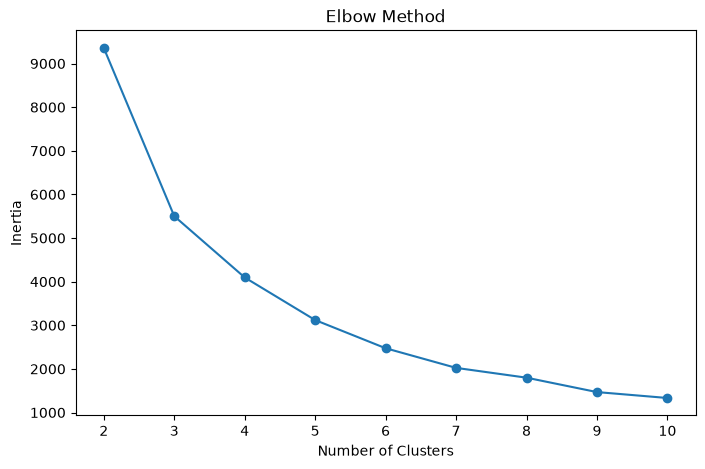

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [10]:
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(
        rfm_scaled
    )

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(
        f"K={k} | Silhouette Score={score:.4f}"
    )

K=2 | Silhouette Score=0.5604
K=3 | Silhouette Score=0.5853
K=4 | Silhouette Score=0.6162
K=5 | Silhouette Score=0.6165
K=6 | Silhouette Score=0.5983
K=7 | Silhouette Score=0.5171
K=8 | Silhouette Score=0.4912
K=9 | Silhouette Score=0.4784
K=10 | Silhouette Score=0.4448


In [11]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

In [12]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [13]:
rfm["Cluster"].value_counts()

Cluster
0    3048
1    1063
3     213
2       8
4       6
Name: count, dtype: int64

In [14]:
cluster_profile = (
    rfm.groupby("Cluster")
       .mean()
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.918635,3.650262,1333.132908
1,248.469426,1.553151,478.648242
2,6.500000,120.500000,55099.491250
3,15.671362,21.286385,12813.941596
4,7.666667,42.833333,190808.536667


In [15]:
cluster_profile.to_csv(
    "../data/cluster_profile.csv"
)

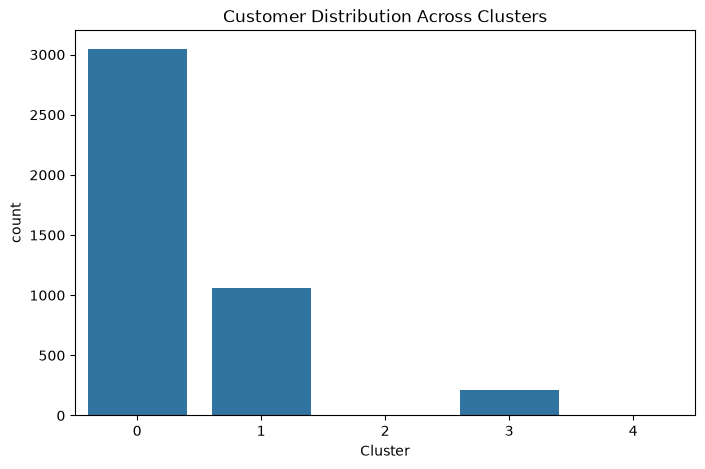

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cluster",
    data=rfm
)

plt.title(
    "Customer Distribution Across Clusters"
)

plt.show()

In [17]:
rfm.to_csv(
    "../data/customer_segments.csv",
    index=True
)

In [18]:
cluster_names = {
    0: "Regular Customers",
    1: "Lost Customers",
    2: "VIP Customers",
    3: "Loyal Customers",
    4: "Champions"
}

rfm["Segment"] = rfm["Cluster"].map(
    cluster_names
)

In [19]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,Lost Customers


In [20]:
rfm["Segment"].value_counts()

Segment
Regular Customers    3048
Lost Customers       1063
Loyal Customers       213
VIP Customers           8
Champions               6
Name: count, dtype: int64

In [21]:
segment_profile = (
    rfm.groupby("Segment")
       [["Recency","Frequency","Monetary"]]
       .mean()
)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
Champions,7.666667,42.833333,190808.536667
Lost Customers,248.469426,1.553151,478.648242
Loyal Customers,15.671362,21.286385,12813.941596
Regular Customers,43.918635,3.650262,1333.132908
VIP Customers,6.500000,120.500000,55099.491250


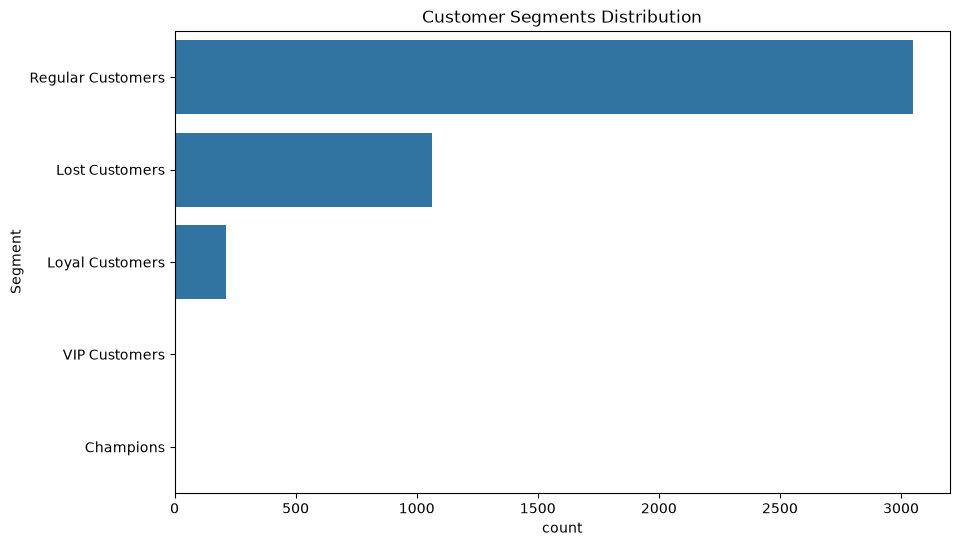

In [22]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    y="Segment",
    order=rfm["Segment"]
          .value_counts()
          .index
)

plt.title(
    "Customer Segments Distribution"
)

plt.show()

In [23]:
rfm.to_csv(
    "../data/customer_segments.csv",
    index=True
)

In [26]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

['../models/kmeans_model.pkl']